Importing Libraries


In [2]:
! pip install scipy

   ---------------------------------------- 0.0/37.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/37.4 MB ? eta -:--:--
   - -------------------------------------- 1.0/37.4 MB 2.6 MB/s eta 0:00:15
   - -------------------------------------- 1.8/37.4 MB 3.1 MB/s eta 0:00:12
   -- ------------------------------------- 2.6/37.4 MB 3.4 MB/s eta 0:00:11
   --- ------------------------------------ 3.7/37.4 MB 3.7 MB/s eta 0:00:10
   ----- ---------------------------------- 5.0/37.4 MB 4.1 MB/s eta 0:00:08
   ------ --------------------------------- 6.0/37.4 MB 4.2 MB/s eta 0:00:08
   ------- -------------------------------- 7.3/37.4 MB 4.5 MB/s eta 0:00:07
   --------- ------------------------------ 8.7/37.4 MB 4.7 MB/s eta 0:00:07
   ---------- ----------------------------- 10.0/37.4 MB 4.8 MB/s eta 0:00:06
   ------------ --------------------------- 11.3/37.4 MB 5.0 MB/s eta 0:00:06
   ------------- -------------------------- 12.8/37.4 MB 5.1 MB/s eta 0:00:05
   -------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings 
import sqlite3 
from scipy.stats import ttest_ind
import scipy.stats as stats 
warnings.filterwarnings('ignore') 


In [2]:
#fetching vendor summary data 
conn = sqlite3.connect(r'C:\Users\Ayush\Downloads\logs\inventory.db')
df = pd.read_sql_query("select * from vendor_sales_summary", conn)
df.head

<bound method NDFrame.head of        VendorNumber                VendorName  Brand  \
0              1128         BROWN-FORMAN CORP   1233   
1              4425     MARTIGNETTI COMPANIES   3405   
2             17035         PERNOD RICARD USA   8068   
3              3960  DIAGEO NORTH AMERICA INC   4261   
4              3960  DIAGEO NORTH AMERICA INC   3545   
...             ...                       ...    ...   
10687          9815            WINE GROUP INC   8527   
10688          8004            SAZERAC CO INC   5683   
10689          3924  HEAVEN HILL DISTILLERIES   9123   
10690          3960  DIAGEO NORTH AMERICA INC   6127   
10691          7245      PROXIMO SPIRITS INC.   3065   

                       Description  purchasePrice  ActualPrice  Volume  \
0          Jack Daniels No 7 Black          26.27        36.99  1750.0   
1            Tito's Handmade Vodka          23.19        28.99  1750.0   
2                 Absolut 80 Proof          18.24        24.99  1750.0   
3

EXPLORATORY DATA ANALYSIS EDA

previously, we examined the various tables in the database to identify key variables understood their relationships, and determine which ones should be included in the final analysis.
In this phase of EDA, we will analyze table to gain insights into the distribution of each column. This will help us to understand data patterns, identify anomalies and ensure data quality before proceeding with further analysis. 

#Summary Statistics 

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
purchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


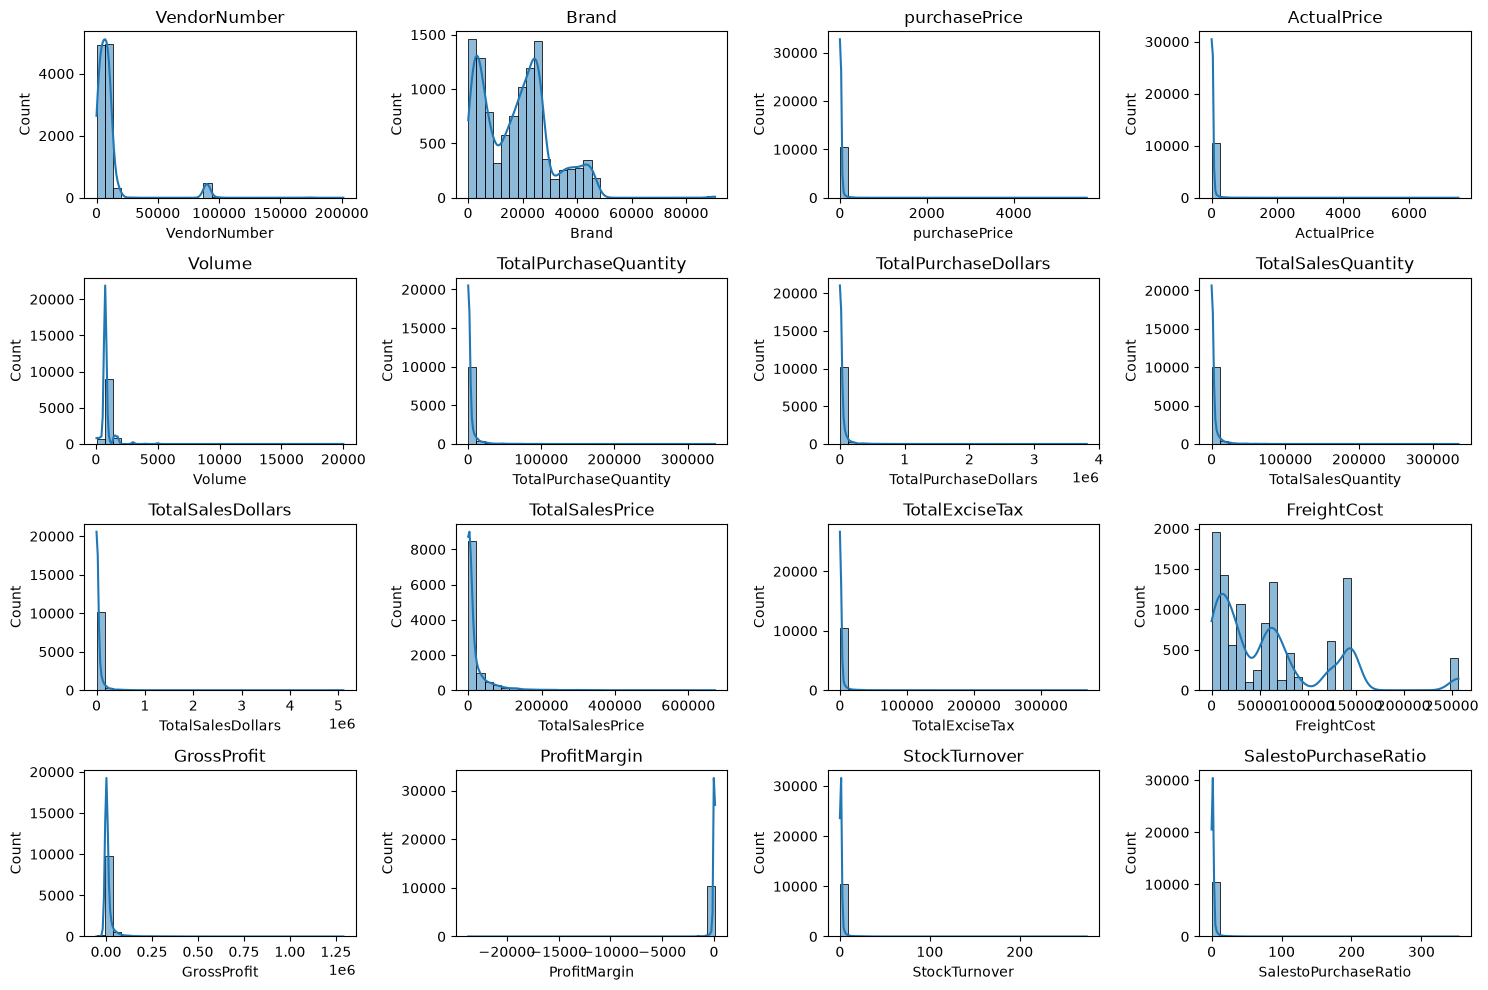

In [4]:
#Distribution plots for numerical columns 
numerical_cols = df.select_dtypes(include = np.number).columns 
plt.figure(figsize = (15,10))
for i, col in enumerate (numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde = True, bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

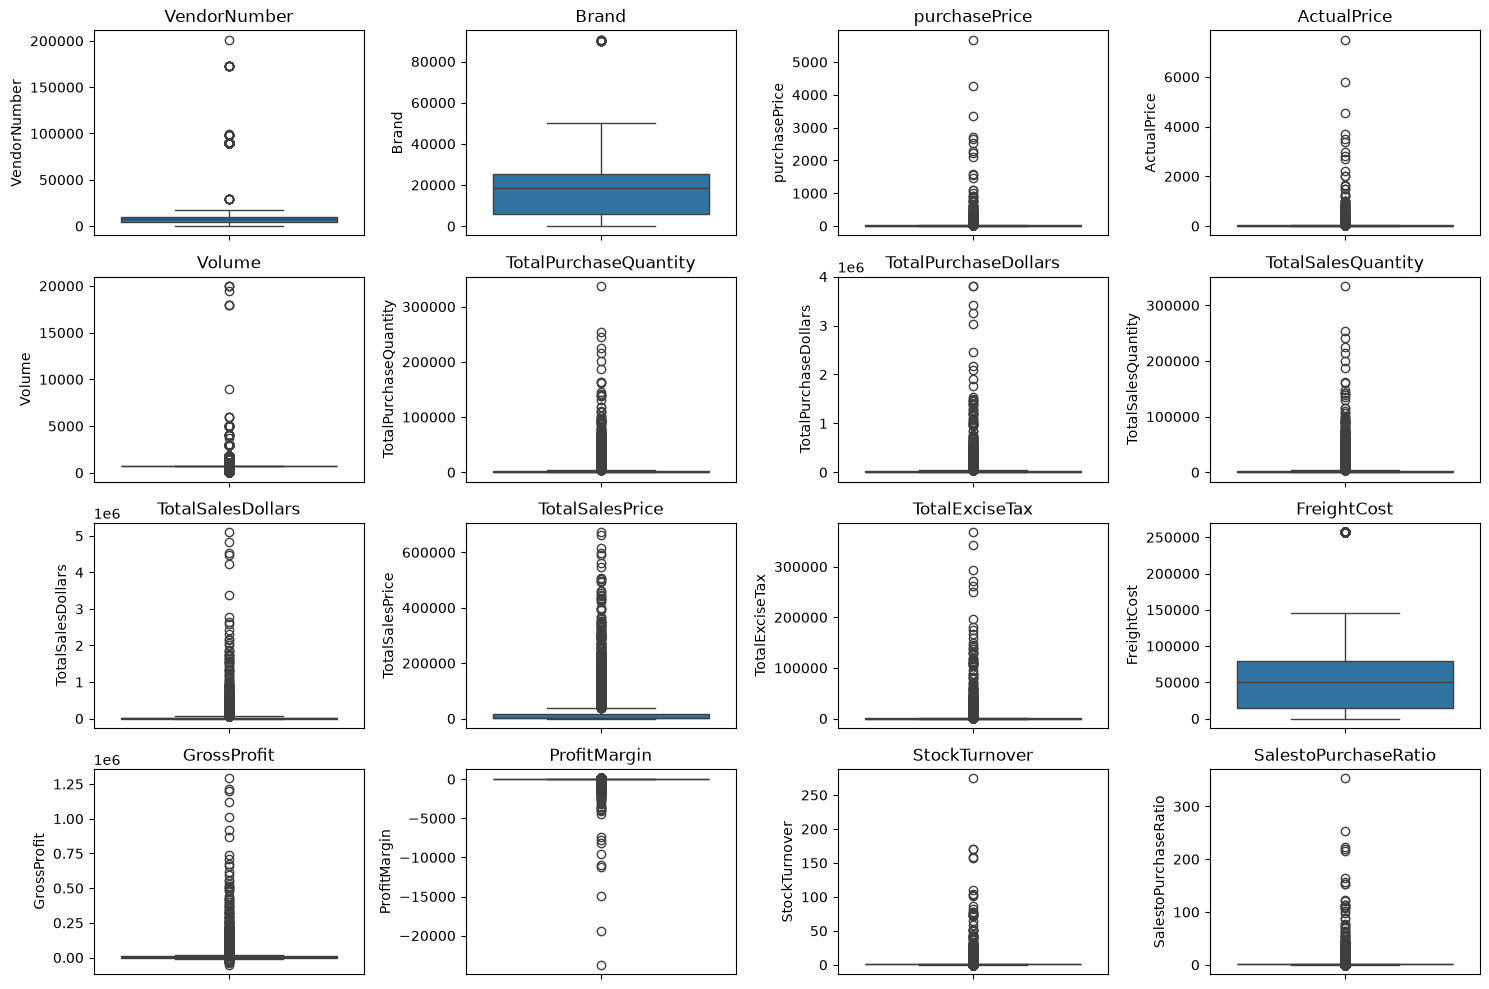

In [5]:
#outline detection with Boxplots 
plt.figure(figsize = (15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y = df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Summary Statistics Insights:

Negative & zero Values:

Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at Discounts lower than the purchase price.

Profit Margin: Has a Minimum of -∞, which suggests cases where revenue is 0 or even lower than costs.  

Total sales Quantity & sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.  

Outliers Indicated by High standard Deviations:  

Purchase & Actual prices: The max values are significantly higher than mean, indicating potential premium products.  

Freight Cost: Huge variation, from 0.09 to 257032.07, suggests logistics inefficiencies or bulk shipments.  

Stock Turnover: Ranges from 0 to 247.5

In [6]:
#let's filter the data by removing the inconsistencies
df = pd.read_sql_query("select * from vendor_sales_summary " \
"where GrossProfit > 0 " \
"and ProfitMargin > 0 " \
"and TotalSalesQuantity > 0 ", conn)
df

,VendorNumber,VendorName,Brand,Description,purchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,72.000000,97.469388


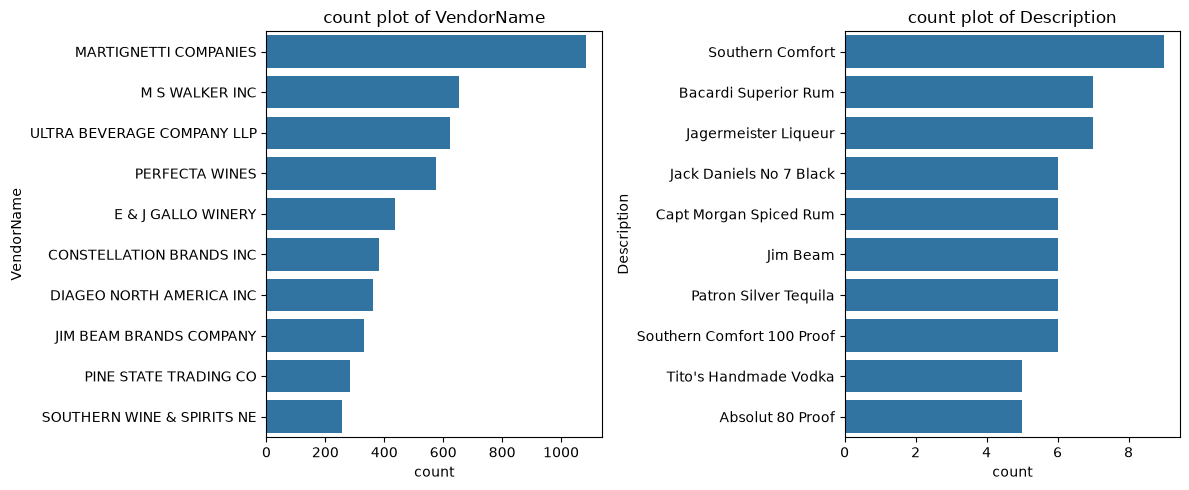

In [7]:
#count plots for categorical Columns
categorical_cols = ["VendorName", "Description"]
plt.figure(figsize = (12,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y = df[col], order = df[col].value_counts().index[:10])
    plt.title(f"count plot of {col}")
plt.tight_layout()
plt.show()

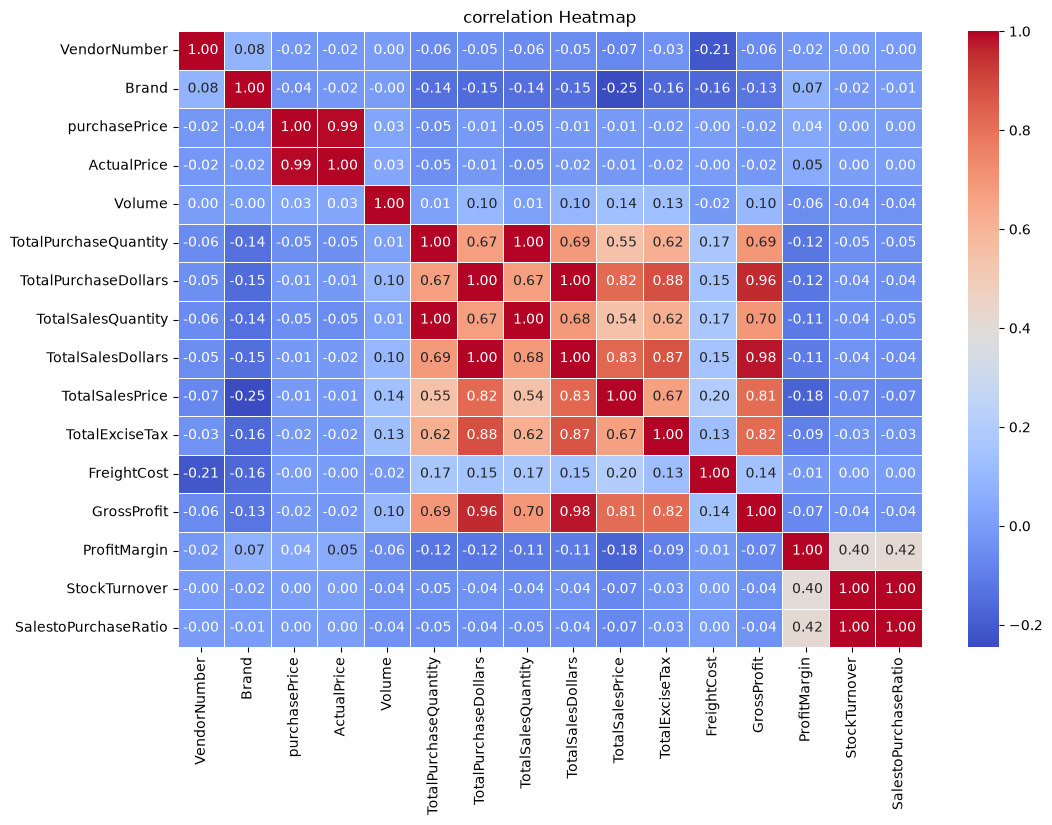

In [8]:
# correlation Heatmap 
plt.figure(figsize = (12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot = True, fmt = " .2f", cmap = "coolwarm", linewidths = 0.5)
plt.title("correlation Heatmap")
plt.show()

# Correlation Insights

* PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that Price variation do not significantly impact sales revenue or profit.
* Strong correlation b/w Total Purchase Quantity and Total Sales Quantity (0.999), confirming efficient inventory turnover.
* Negative correlation b/w Profit Margin & Total Sales Price (-0.179) suggests that as sales Price increases, Margins Decrease, possibly due to competitive pricing pressures.
* StockTurnover has weak negative correlations with both GrossProfit (-0.0...) and Profit Margin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

Solving Bussiness Problems Using Data Analysis

1) Identify Brands that needs Promotional or pricing Adjustments which exhibit lower sales performance but higher profit margins

In [9]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars' : 'sum',
    'ProfitMargin' : 'mean'}).reset_index()

In [10]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)


In [11]:
low_sales_threshold

np.float64(560.299)

In [12]:
high_margin_threshold

np.float64(64.97017552750113)

In [13]:
#Filter Brands with low sales but high profit margins
target_brands = brand_performance[(brand_performance['TotalSalesDollars'] <= low_sales_threshold) & 
                                  (brand_performance['ProfitMargin'] >= high_margin_threshold)]
print("Brands with low sales but high progit margins: ")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with low sales but high progit margins: 


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [14]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars'] < 10000]

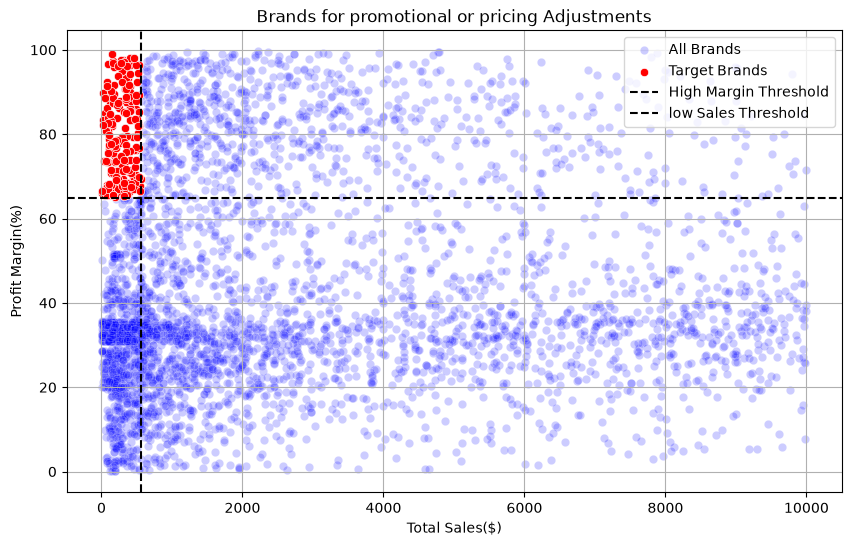

In [15]:
plt.figure(figsize = (10,6))
sns.scatterplot(data = brand_performance, x = 'TotalSalesDollars', y = 'ProfitMargin', color = "Blue", label = "All Brands", alpha = 0.2)
sns.scatterplot(data = target_brands, x = 'TotalSalesDollars', y = 'ProfitMargin', color = "red", label = "Target Brands")
plt.axhline(high_margin_threshold, linestyle = '--', color = "black", label = "High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle = '--', color = "black", label = "low Sales Threshold")
plt.xlabel("Total Sales($)")
plt.ylabel("Profit Margin(%)")
plt.title("Brands for promotional or pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()


Top Vendors and Brands by Sales Performance 

In [16]:
def format_dollars(value):
    if value >= 1_00_000:
        return f"{value/1_00_000:.2f}M"
    elif value >= 1_000:
        return f"{value/1_000:.2f}K"
    else: 
        return str(value)

In [17]:
#top Vendors and Brands by Sales performance
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands  = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors



VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64

In [18]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [19]:
top_brands.apply(lambda x: format_dollars(x))

Description
Jack Daniels No 7 Black    79.65M
Tito's Handmade Vodka      74.00M
Grey Goose Vodka           72.10M
Capt Morgan Spiced Rum     63.56M
Absolut 80 Proof           62.45M
Jameson Irish Whiskey      57.16M
Ketel One Vodka            50.70M
Baileys Irish Cream        41.50M
Kahlua                     36.05M
Tanqueray                  34.57M
Name: TotalSalesDollars, dtype: str

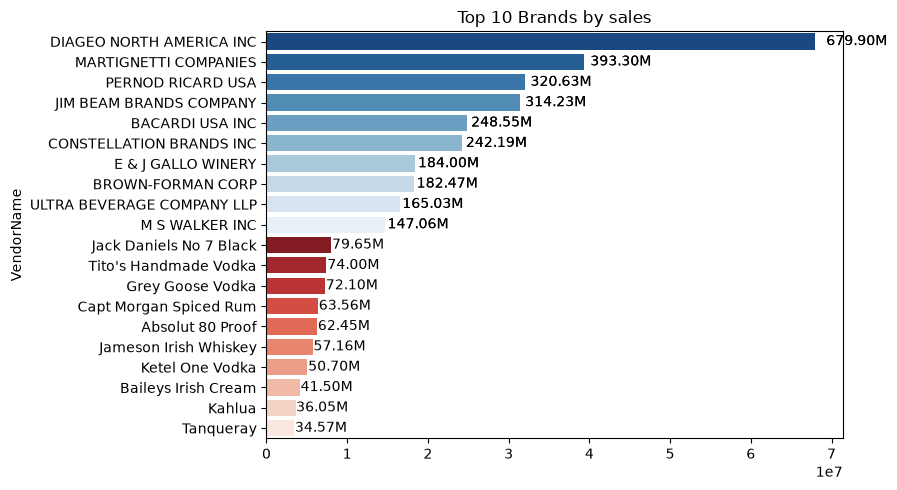

In [20]:
plt.figure(figsize = (15,5))

#plot for top vendors 
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y = top_vendors.index, x = top_vendors.values, palette = "Blues_r")
plt.title("Top 10 Vendors by sales")
for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height()/2,
             format_dollars(bar.get_width()),
             ha = 'left', va = 'center', fontsize = 10, color = 'black')

#plot for top Brands
plt.subplot(1, 2, 1)
ax2 = sns.barplot(y = top_brands.index.astype(str), x = top_brands.values, palette = "Reds_r")
plt.title("Top 10 Brands by sales")
for bar in ax1.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height()/2,
             format_dollars(bar.get_width()),
             ha = 'left', va = 'center', fontsize = 10, color = 'black')

plt.tight_layout()
plt.show()
             


Which Vendors Contribute the most to Total Purchase Dollars

In [21]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars' : 'sum', 
    'GrossProfit' : 'sum',
    'TotalSalesDollars' : 'sum'
}).reset_index()

In [35]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()

In [36]:
round(vendor_performance.sort_values('PurchaseContribution%', ascending = False),2)

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,0.16
57,MARTIGNETTI COMPANIES,25502095.83,13828263.53,39330359.36,0.08
68,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,0.08
46,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,0.08
6,BACARDI USA INC,17432020.26,7422796.88,24854817.14,0.06
...,...,...,...,...,...
33,FANTASY FINE WINES CORP,128.64,198.95,327.59,0.00
107,UNCORKED,118.74,58.20,176.94,0.00
85,SILVER MOUNTAIN CIDERS,77.18,265.33,342.51,0.00
16,CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.00


In [39]:
#Display Top 10 Vendors
top_vendors = vendor_performance.nlargest(10, 'PurchaseContribution%')
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,500.97M,178.93M,679.90M,0.163003
57,MARTIGNETTI COMPANIES,255.02M,138.28M,393.30M,0.082977
68,PERNOD RICARD USA,238.51M,82.12M,320.63M,0.077606
46,JIM BEAM BRANDS COMPANY,234.94M,79.29M,314.23M,0.076444
6,BACARDI USA INC,174.32M,74.23M,248.55M,0.056719
20,CONSTELLATION BRANDS INC,152.74M,89.45M,242.19M,0.049697
11,BROWN-FORMAN CORP,132.39M,50.08M,182.47M,0.043076
30,E & J GALLO WINERY,120.69M,63.31M,184.00M,0.039268
106,ULTRA BEVERAGE COMPANY LLP,111.67M,53.35M,165.03M,0.036335
53,M S WALKER INC,97.64M,49.42M,147.06M,0.031771


In [40]:
top_vendors['CumulativeContribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,CumulativeContribution%
25,DIAGEO NORTH AMERICA INC,500.97M,178.93M,679.90M,0.163003,0.163003
57,MARTIGNETTI COMPANIES,255.02M,138.28M,393.30M,0.082977,0.245981
68,PERNOD RICARD USA,238.51M,82.12M,320.63M,0.077606,0.323586
46,JIM BEAM BRANDS COMPANY,234.94M,79.29M,314.23M,0.076444,0.400031
6,BACARDI USA INC,174.32M,74.23M,248.55M,0.056719,0.456750
20,CONSTELLATION BRANDS INC,152.74M,89.45M,242.19M,0.049697,0.506447
11,BROWN-FORMAN CORP,132.39M,50.08M,182.47M,0.043076,0.549523
30,E & J GALLO WINERY,120.69M,63.31M,184.00M,0.039268,0.588791
106,ULTRA BEVERAGE COMPANY LLP,111.67M,53.35M,165.03M,0.036335,0.625125
53,M S WALKER INC,97.64M,49.42M,147.06M,0.031771,0.656896


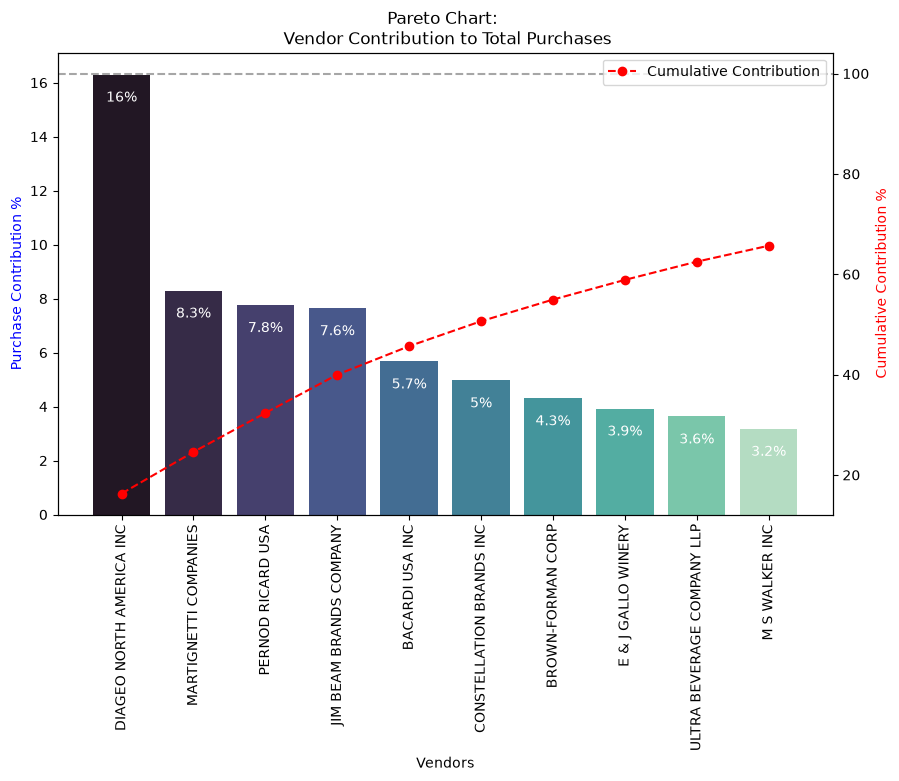

In [51]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# 1. Scale the decimal data by 100 for plotting
purchase_pct = top_vendors['PurchaseContribution%'] * 100
cumulative_pct = top_vendors['CumulativeContribution%'] * 100

# Bar plot for Purchase Contribution %
sns.barplot(x=top_vendors['VendorName'], 
            y=purchase_pct, 
            palette="mako", ax=ax1)

for i, value in enumerate(purchase_pct):
    # 2. Format the label to show 1 to 2 decimal places cleanly
    label_text = f"{value:.2g}%" 
    ax1.text(i, value - 1, label_text, 
             ha='center', fontsize=10, color='white')

# Line plot for Cumulative Contribution %
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], 
         cumulative_pct, 
         color='red', marker='o', 
         linestyle='dashed', label='Cumulative Contribution')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')

ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: \n Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')
plt.show()

In [44]:
#How Much of Total Procuremnet is Dependent on the Top Vendors
print(f"Total Purchase Contribution of Top 10 Vendors is {round(top_vendors['PurchaseContribution%'].sum()*100,2)}%")

Total Purchase Contribution of Top 10 Vendors is 65.69%


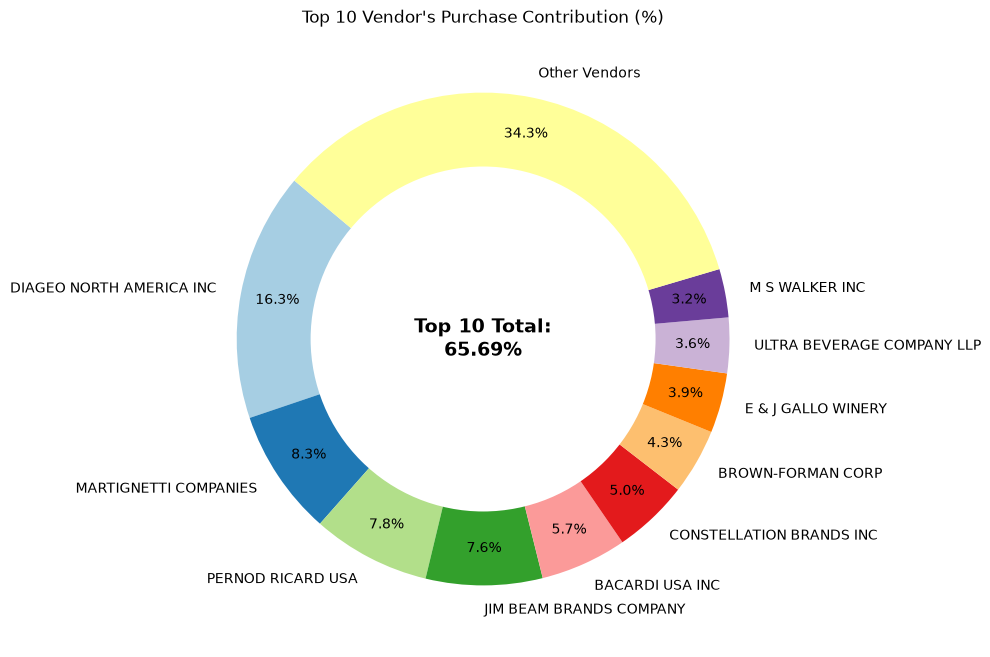

In [47]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = [val * 100 for val in top_vendors['PurchaseContribution%'].values]
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%', startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

# Does Purchasing in bulk reduce the unit price and what is the Optimal Purchase Volume for cost savings


In [52]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [53]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels = ["Small", "Medium", "large"])

In [54]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
large,10.777625


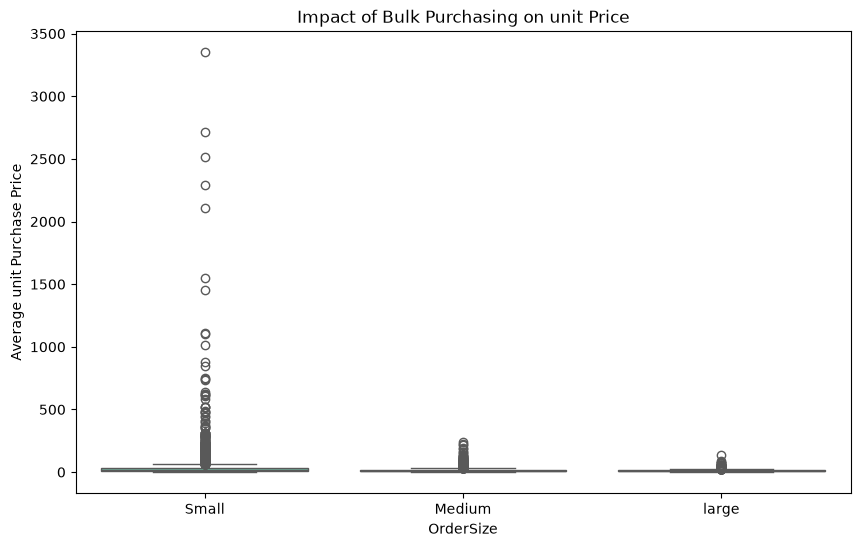

In [57]:
plt.figure(figsize = (10, 6))
sns.boxplot(data = df, x = "OrderSize", y = "UnitPurchasePrice", palette = "Set2")
plt.title("Impact of Bulk Purchasing on unit Price")
plt.xlabel("OrderSize")
plt.ylabel("Average unit Purchase Price")
plt.show()

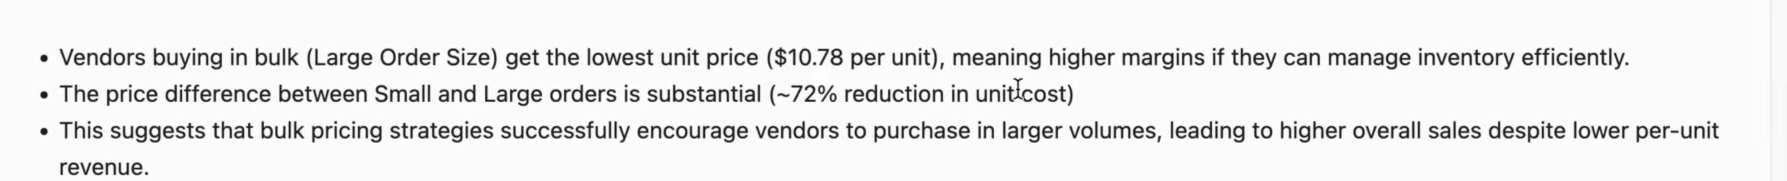


Which Vendors have low Inventory Turnover, Indicating excess stock and slow-moving products

In [58]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending = True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


#How Much capital is Located in Unsold Inventory Per Vendor, and Which Vendors Contribute the most to it?

In [66]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"]-df["TotalSalesQuantity"])*df["purchasePrice"]
print('Total Unsold Capital: ', format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital:  27.08M


In [75]:
#Aggregate Capital Locked per Vendor
inventory_vendor_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()
#Sort Vendors with the highest locked Capital
inventory_vendor_per_vendor = inventory_vendor_per_vendor.sort_values(by = "UnsoldInventoryValue", ascending = False)
inventory_vendor_per_vendor['UnsoldInventoryValue'] = inventory_vendor_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_vendor_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,7.22M
46,JIM BEAM BRANDS COMPANY,5.55M
68,PERNOD RICARD USA,4.71M
116,WILLIAM GRANT & SONS INC,4.02M
30,E & J GALLO WINERY,2.28M
79,SAZERAC CO INC,1.98M
11,BROWN-FORMAN CORP,1.78M
20,CONSTELLATION BRANDS INC,1.34M
61,MOET HENNESSY USA INC,1.26M
77,REMY COINTREAU USA INC,1.19M


#What is the 95% Confidence Intervals for Profit Margins of Top-Performing and low-Performing Vendors

In [76]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [80]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"]<= low_threshold]["ProfitMargin"].dropna()

In [81]:
top_vendors

0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
3523    79.684817
3681    85.782102
4751    93.085860
4920    95.012530
5050    94.271857
Name: ProfitMargin, Length: 2141, dtype: float64

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


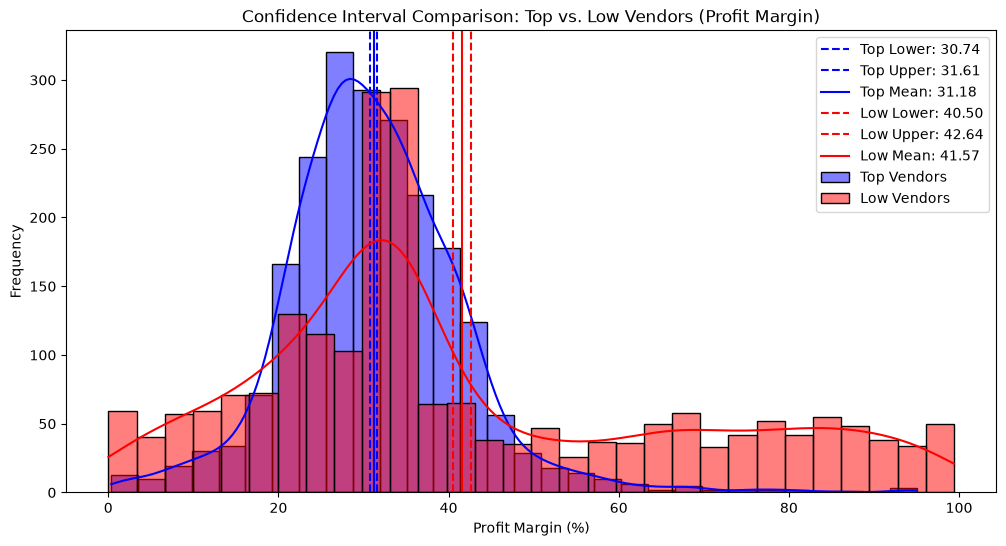

In [82]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()

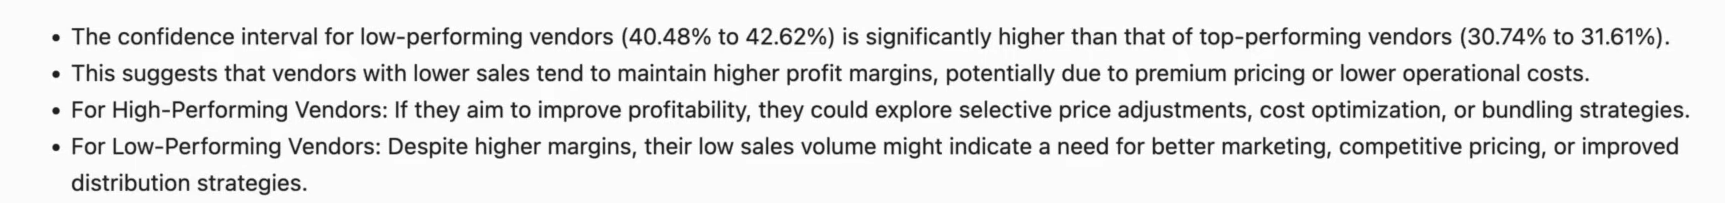

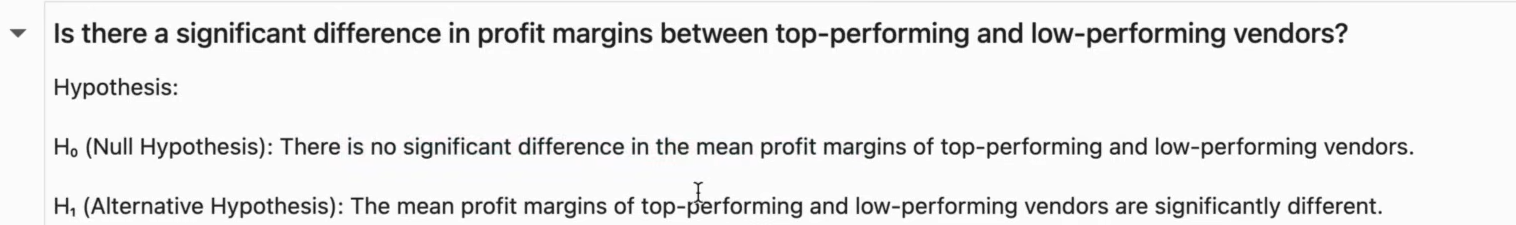

In [83]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")

T-Statistic: -17.6695, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.
